# Taller 4: Detección de contornos

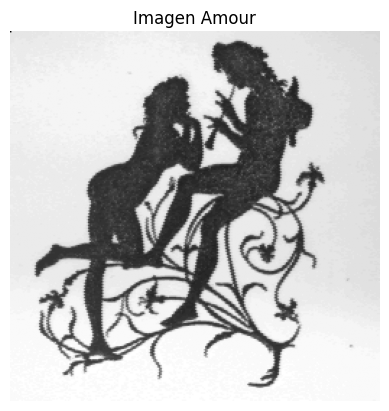

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import sobel, prewitt
from skimage import exposure
from skimage.filters import laplace
from skimage.filters import gaussian
from skimage.filters import threshold_local
from skimage.segmentation import flood
from skimage.feature import canny
PATH = "./imagenes/"
imagen = cv2.imread(PATH + "AMOUR.png", cv2.IMREAD_GRAYSCALE)
imagen_int16 = imagen.astype(np.int16)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Amour')
plt.axis('off')
plt.show()

Utilizamos umbralización local para y crecimiento de regiones para obtener una imagen binaria.

In [24]:
threshold = threshold_local(imagen, block_size=151, method='mean')
binary_image = imagen > threshold
thresholded_image = (binary_image*255).astype(np.uint8)
seed = (100, 100)
imagen_final = flood(thresholded_image, seed, tolerance=10)

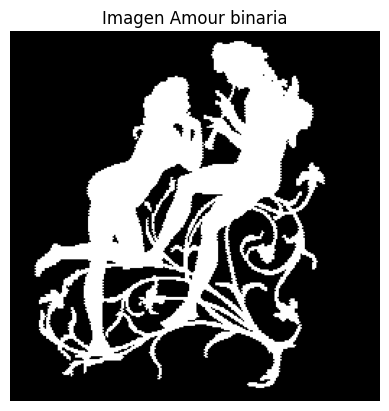

In [29]:
plt.imshow(imagen_final, cmap='gray')
plt.title('Imagen Amour binaria')
plt.axis('off')
plt.show()

Aplicamos Canny con un valor bajo para sigma.

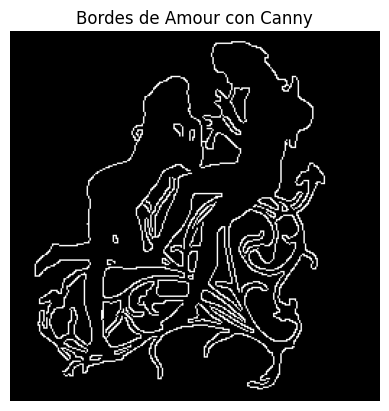

In [30]:
edges = canny(imagen_final, sigma=1, low_threshold=0, high_threshold=1)
plt.imshow(edges, cmap='gray')
plt.title('Bordes de Amour con Canny')
plt.axis('off')
plt.show()

Obtenemos la imagen final superponiendo los bordes a la imagen inicial.

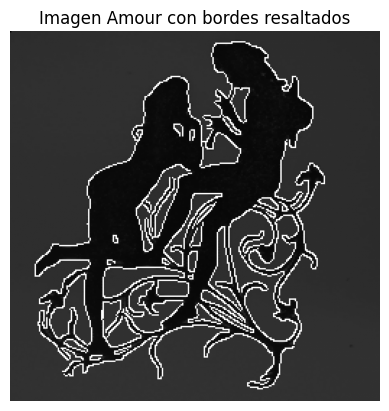

In [31]:
outlined = imagen.copy()
outlined[edges] = 255
plt.imshow(outlined, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('Imagen Amour con bordes resaltados')
plt.show()

## Bono

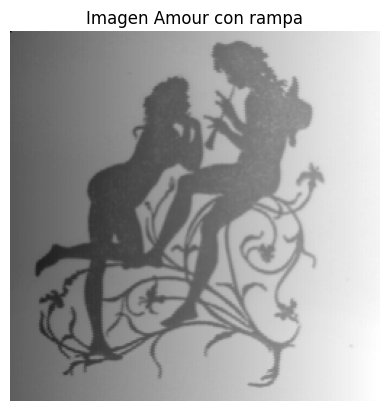

In [33]:
imagen_bono = cv2.imread(PATH + "AMOUR_AVEC_RAMPE.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen_bono, cmap='gray')
plt.title('Imagen Amour con rampa')
plt.axis('off')
plt.show()

In [34]:
threshold_bono = threshold_local(imagen_bono, block_size=151, method='mean')
binary_image_bono = imagen_bono > threshold_bono
thresholded_image_bono = (binary_image_bono*255).astype(np.uint8)
seed = (100, 100)
imagen_bono_binaria = flood(thresholded_image_bono, seed, tolerance=10)

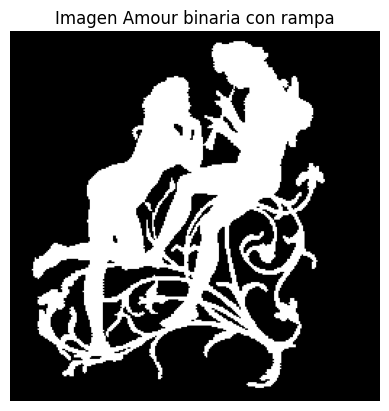

In [35]:
plt.imshow(imagen_bono_binaria, cmap='gray')
plt.axis('off')
plt.title('Imagen Amour binaria con rampa')
plt.show()

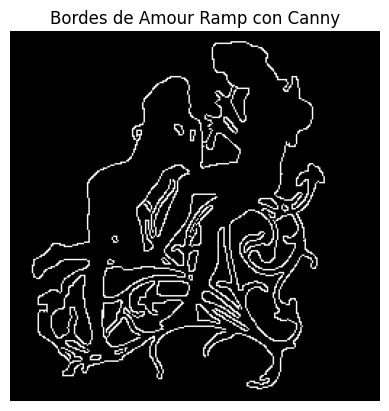

In [36]:
edges_bono = canny(imagen_bono_binaria, sigma=1, low_threshold=0, high_threshold=1)
plt.imshow(edges_bono, cmap='gray')
plt.title('Bordes de Amour Ramp con Canny')
plt.axis('off')
plt.show()

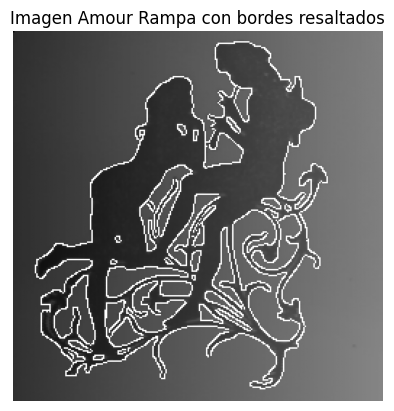

In [37]:
outlined_bono= imagen_bono.copy()
outlined_bono[edges_bono] = 255
plt.imshow(outlined_bono, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('Imagen Amour Rampa con bordes resaltados')
plt.show()